In [1]:
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import numpy as np
import matplotlib.pyplot as plt

In [2]:
RANDOM_STATE = 1221182
torch.manual_seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
print("Librerías cargadas correctamente.")

Librerías cargadas correctamente.


In [3]:
bonafide = pd.read_csv("../../Dataset/Features/bonafide_features.csv")
spoof    = pd.read_csv("../../Dataset/Features/spoof_features.csv")
df = pd.concat([bonafide, spoof], ignore_index=True)

# ── Separar features y etiquetas ────────────────────────────────────────────
X = df.drop(['label', 'filename'], axis=1, errors='ignore').select_dtypes(include=[np.number])
y = df['label']

print(f"Total muestras : {len(df)}")
print(f"Distribución de clases:\n{y.value_counts()}")
print(f"Número de features: {X.shape[1]}")

# ── Verificar desbalance ────────────────────────────────────────────────────
class_counts = y.value_counts()
ratio = class_counts.max() / class_counts.min()
print(f"\nRatio de desbalance: {ratio:.2f}x")
if ratio > 1.5:
    print("⚠️  Desbalance detectado — se usarán pesos de clase en la pérdida.")

Total muestras : 100
Distribución de clases:
label
1    50
0    50
Name: count, dtype: int64
Número de features: 29

Ratio de desbalance: 1.00x


In [4]:
# ── Escalado y split ────────────────────────────────────────────────────────
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y,
    test_size=0.2,
    stratify=y,
    random_state=RANDOM_STATE
)

# ── Tensores ─────────────────────────────────────────────────────────────────
X_train_t = torch.FloatTensor(X_train)
y_train_t = torch.LongTensor(y_train.values)
X_test_t  = torch.FloatTensor(X_test)
y_test_t  = torch.LongTensor(y_test.values)

# ── Pesos de clase para manejar desbalance ───────────────────────────────────
class_counts_train = np.bincount(y_train.values)
class_weights = torch.FloatTensor(len(y_train) / (len(class_counts_train) * class_counts_train))
print(f"Pesos de clase para CrossEntropy: {class_weights.numpy()}")

print(f"\nTrain: {len(X_train)} muestras | Test: {len(X_test)} muestras")

Pesos de clase para CrossEntropy: [1. 1.]

Train: 80 muestras | Test: 20 muestras


In [ ]:
class ProtoPNet(nn.Module):
    """
    ProtoPNet para clasificación tabular bonafide/spoof.

    Arquitectura:
        Encoder  --> espacio latente de 32 dims
        Prototipos --> num_prototypes vectores aprendibles en ese espacio
        Clasificador --> capa lineal sin sesgo sobre las similitudes

    Parámetros
    ----------
    input_dim      : dimensión de las features de entrada
    num_prototypes : número total de prototipos (repartidos entre clases)
    latent_dim     : dimensión del espacio latente
    num_classes    : número de clases (2 por defecto)
    """
    def __init__(self, input_dim: int, num_prototypes: int = 10,
                 latent_dim: int = 32, num_classes: int = 2):
        super().__init__()
        assert num_prototypes % num_classes == 0, \
            "num_prototypes debe ser divisible entre num_classes"

        self.num_prototypes = num_prototypes
        self.num_classes    = num_classes
        self.protos_per_class = num_prototypes // num_classes

        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 64), nn.ReLU(),
            nn.Linear(64, latent_dim)
        )
        self.prototypes  = nn.Parameter(torch.randn(num_prototypes, latent_dim))
        self.classifier  = nn.Linear(num_prototypes, num_classes, bias=False)

        # Máscara de conexión prototipo → clase (solo prototipos de la misma clase)
        # Forma (num_classes, num_prototypes) — se usa para inicializar y penalizar
        self._proto_class_identity = torch.zeros(num_classes, num_prototypes)
        for c in range(num_classes):
            start = c * self.protos_per_class
            end   = start + self.protos_per_class
            self._proto_class_identity[c, start:end] = 1.0

    def forward(self, x: torch.Tensor):
        emb        = self.encoder(x)                          # (B, latent_dim)
        distances  = torch.cdist(emb, self.prototypes)        # (B, num_prototypes)
        similarity = torch.exp(-distances)                    # (B, num_prototypes)
        logits     = self.classifier(similarity)              # (B, num_classes)
        return logits, similarity, distances

    def prototype_class_identity(self, device):
        return self._proto_class_identity.to(device)


INPUT_DIM = X_train.shape[1]
model = ProtoPNet(input_dim=INPUT_DIM, num_prototypes=10)
print(model)
print(f"\nPrototipos por clase: {model.protos_per_class}")

ProtoPNet(
  (encoder): Sequential(
    (0): Linear(in_features=29, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=32, bias=True)
  )
  (classifier): Linear(in_features=10, out_features=2, bias=False)
)

Prototipos por clase: 5


In [ ]:
def separation_loss(distances: torch.Tensor, labels: torch.Tensor,
                    model: ProtoPNet) -> tuple[torch.Tensor, torch.Tensor]:
    """
    Calcula R1 y R2.

    R1 (cluster loss)   : para cada prototipo, distancia mínima a muestras de su clase,
                          los prototipos "viven" dentro de su clase
    R2 (separation loss): para cada muestra, distancia mínima a prototipos de su propia clase, 
                          cada muestra tiene un prototipo cercano de su clase
    """
    device = distances.device
    pci    = model.prototype_class_identity(device)  # (num_classes, num_protos)
    B      = distances.shape[0]

    # ── R1: cluster loss ─────────────────────────────────────────────────────
    cluster_loss = torch.zeros(1, device=device)
    for c in range(model.num_classes):
        mask   = (labels == c)                           # muestras de clase c
        if mask.sum() == 0:
            continue
        proto_idx = (pci[c] == 1).nonzero(as_tuple=True)[0]  # prototipos de clase c
        d_subset  = distances[mask][:, proto_idx]             # (n_c, protos_c)
        # distancia mínima de cada prototipo a alguna muestra de su clase
        cluster_loss = cluster_loss + d_subset.min(dim=0).values.mean()

    # ── R2: separation loss ──────────────────────────────────────────────────
    sep_loss = torch.zeros(1, device=device)
    for c in range(model.num_classes):
        mask      = (labels == c)
        if mask.sum() == 0:
            continue
        proto_idx = (pci[c] == 1).nonzero(as_tuple=True)[0]
        d_subset  = distances[mask][:, proto_idx]            # (n_c, protos_c)
        sep_loss  = sep_loss + d_subset.min(dim=1).values.mean()

    return cluster_loss, sep_loss


# ── Hiperparámetros ───────────────────────────────────────────────────────────
EPOCHS    = 100
LR        = 0.001
LAMBDA_R1 = 0.1
LAMBDA_R2 = 0.1 

criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = optim.Adam(model.parameters(), lr=LR)

history = {'loss': [], 'ce': [], 'r1': [], 'r2': []}

model.train()
for epoch in range(EPOCHS):
    logits, similarity, distances = model(X_train_t)

    l_ce       = criterion(logits, y_train_t)
    l_r1, l_r2 = separation_loss(distances, y_train_t, model)
    loss       = l_ce + LAMBDA_R1 * l_r1 + LAMBDA_R2 * l_r2

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    history['loss'].append(loss.item())
    history['ce'].append(l_ce.item())
    history['r1'].append(l_r1.item())
    history['r2'].append(l_r2.item())

    if (epoch + 1) % 20 == 0:
        print(f"Epoch [{epoch+1:>3}/{EPOCHS}] "
              f"Loss: {loss.item():.4f} "
              f"(CE: {l_ce.item():.4f} | R1: {l_r1.item():.4f} | R2: {l_r2.item():.4f})")

print("\n✅ Entrenamiento completado.")

Epoch [ 20/100] Loss: 2.2493 (CE: 0.6909 | R1: 8.9038 | R2: 6.6810)
Epoch [ 40/100] Loss: 1.9231 (CE: 0.6788 | R1: 7.9014 | R2: 4.5408)
Epoch [ 60/100] Loss: 1.7107 (CE: 0.6636 | R1: 7.1358 | R2: 3.3350)
Epoch [ 80/100] Loss: 1.5805 (CE: 0.6466 | R1: 6.4507 | R2: 2.8879)
Epoch [100/100] Loss: 1.4659 (CE: 0.6323 | R1: 5.6120 | R2: 2.7245)

✅ Entrenamiento completado.


In [7]:
def push_prototypes(model: ProtoPNet,
                    X_t: torch.Tensor,
                    y_t: torch.Tensor) -> dict:
    """
    Reemplaza cada prototipo por la muestra de entrenamiento de su clase
    más cercana en el espacio latente. Devuelve índices de las muestras
    elegidas por cada prototipo.
    """
    model.eval()
    with torch.no_grad():
        embeddings = model.encoder(X_t)          # (N, latent_dim)

    pci          = model.prototype_class_identity(embeddings.device)
    proto_indices = {}                            # prototipo → índice de muestra

    with torch.no_grad():
        for c in range(model.num_classes):
            class_mask = (y_t == c)
            class_emb  = embeddings[class_mask]  # embeddings de clase c
            class_idx  = class_mask.nonzero(as_tuple=True)[0]  # índices originales

            proto_idx_global = (pci[c] == 1).nonzero(as_tuple=True)[0]
            for j in proto_idx_global:
                proto_vec = model.prototypes[j]               # (latent_dim,)
                dists     = torch.norm(class_emb - proto_vec, dim=1)  # (n_c,)
                nearest   = torch.argmin(dists).item()
                nearest_global = class_idx[nearest].item()

                # Reemplazar el prototipo con esa muestra
                model.prototypes[j] = class_emb[nearest].clone()
                proto_indices[j.item()] = {
                    'sample_idx'   : nearest_global,
                    'clase'        : c,
                    'dist_previa'  : dists[nearest].item()
                }

    return proto_indices


proto_info = push_prototypes(model, X_train_t, y_train_t)
print("Push step completado. Prototipos anclados a muestras reales:\n")
print(f"{'Proto ID':>8} | {'Clase':>6} | {'Sample Idx':>10} | {'Dist antes':>10}")
print("-" * 45)
for pid, info in sorted(proto_info.items()):
    nombre_clase = 'REAL' if info['clase'] == 1 else 'FAKE'
    print(f"{pid:>8} | {nombre_clase:>6} | {info['sample_idx']:>10} | {info['dist_previa']:>10.4f}")

Push step completado. Prototipos anclados a muestras reales:

Proto ID |  Clase | Sample Idx | Dist antes
---------------------------------------------
       0 |   FAKE |         78 |     4.2204
       1 |   FAKE |          5 |     4.2232
       2 |   FAKE |         17 |     2.5409
       3 |   FAKE |         34 |     2.0715
       4 |   FAKE |          3 |     0.0161
       5 |   REAL |         43 |     0.0111
       6 |   REAL |         54 |     3.0401
       7 |   REAL |         37 |     4.2670
       8 |   REAL |         65 |     3.1575
       9 |   REAL |         54 |     4.2952


 REPORTE DE CLASIFICACIÓN
              precision    recall  f1-score   support

    FAKE (0)       0.77      1.00      0.87        10
    REAL (1)       1.00      0.70      0.82        10

    accuracy                           0.85        20
   macro avg       0.88      0.85      0.85        20
weighted avg       0.88      0.85      0.85        20



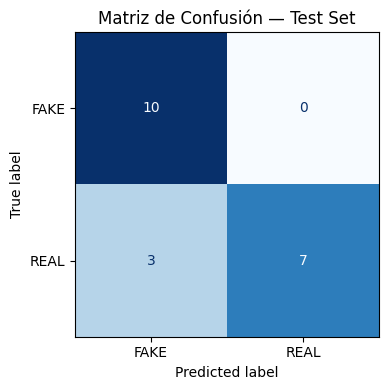


Equal Error Rate (EER): 0.0000  |  Umbral EER: 0.0486


In [8]:
model.eval()
with torch.no_grad():
    logits_test, sim_test, _ = model(X_test_t)
    preds = torch.argmax(logits_test, dim=1).numpy()

y_true = y_test.values

print("=" * 55)
print(" REPORTE DE CLASIFICACIÓN")
print("=" * 55)
print(classification_report(
    y_true, preds,
    target_names=['FAKE (0)', 'REAL (1)']
))

# ── Matriz de confusión ───────────────────────────────────────────────────────
cm = confusion_matrix(y_true, preds)
fig, ax = plt.subplots(figsize=(5, 4))
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=['FAKE', 'REAL'])
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Matriz de Confusión — Test Set')
plt.tight_layout()
plt.show()

# ── Equal Error Rate (EER) — métrica estándar en anti-spoofing ────────────────
from sklearn.metrics import roc_curve
scores = sim_test[:, model.protos_per_class:].mean(dim=1).numpy()  # similitud media con prototipos REAL
fpr, tpr, thresholds = roc_curve(y_true, scores)
fnr = 1 - tpr
eer_threshold = thresholds[np.nanargmin(np.abs(fnr - fpr))]
eer = fpr[np.nanargmin(np.abs(fnr - fpr))]
print(f"\nEqual Error Rate (EER): {eer:.4f}  |  Umbral EER: {eer_threshold:.4f}")

 Muestra #12
 Etiqueta real : REAL
 Predicción    : REAL (confianza: 50.50%)

Proto ID |  Clase |  Similitud |  Distancia
---------------------------------------------
       5 |   REAL |     0.3038 |     1.1914
       7 |   REAL |     0.2475 |     1.3962
       9 |   REAL |     0.0518 |     2.9596
       6 |   REAL |     0.0518 |     2.9596
       1 |   FAKE |     0.0425 |     3.1592
       8 |   REAL |     0.0408 |     3.1993
       0 |   FAKE |     0.0192 |     3.9509
       3 |   FAKE |     0.0110 |     4.5067
       2 |   FAKE |     0.0089 |     4.7170
       4 |   FAKE |     0.0067 |     5.0076


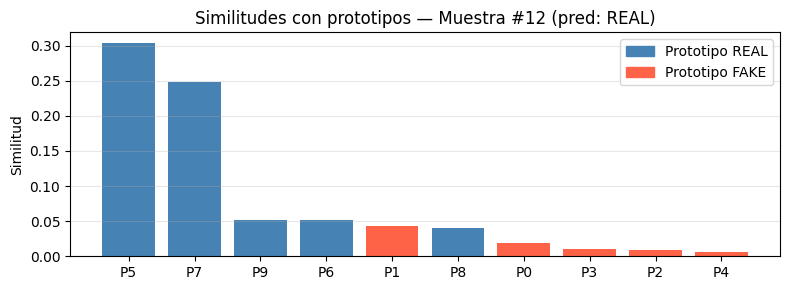

 Muestra #0
 Etiqueta real : FAKE
 Predicción    : FAKE (confianza: 52.83%)

Proto ID |  Clase |  Similitud |  Distancia
---------------------------------------------
       4 |   FAKE |     0.4701 |     0.7549
       1 |   FAKE |     0.0763 |     2.5737
       3 |   FAKE |     0.0433 |     3.1403
       0 |   FAKE |     0.0407 |     3.2023
       7 |   REAL |     0.0171 |     4.0660
       2 |   FAKE |     0.0167 |     4.0929
       9 |   REAL |     0.0139 |     4.2728
       6 |   REAL |     0.0139 |     4.2728
       5 |   REAL |     0.0047 |     5.3685
       8 |   REAL |     0.0040 |     5.5113


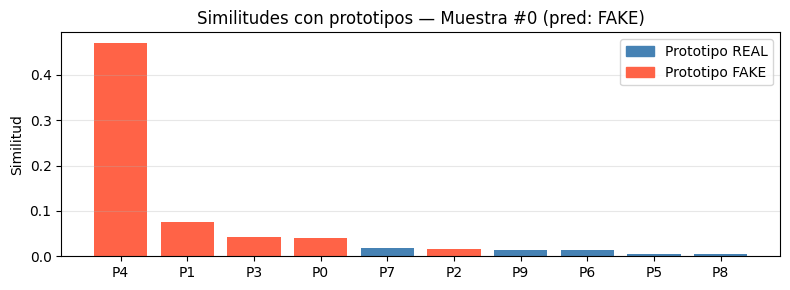

In [12]:
def explicar_con_prototipos(idx_muestra: int,
                             top_k: int = 3,
                             mostrar_grafico: bool = True):
    """
    Explica la predicción de una muestra del test set.

    Muestra:
      - Predicción final
      - Similitudes con todos los prototipos ordenadas
      - Clase de cada prototipo
      - Gráfico de barras de similitudes (opcional)
    """
    model.eval()
    muestra = X_test_t[idx_muestra].unsqueeze(0)

    with torch.no_grad():
        logits, similarity, distances = model(muestra)

    pred  = torch.argmax(logits).item()
    sims  = similarity[0].numpy()
    confianza = torch.softmax(logits, dim=1)[0][pred].item()

    etiqueta_real = 'REAL' if y_test.values[idx_muestra] == 1 else 'FAKE'
    etiqueta_pred = 'REAL' if pred == 1 else 'FAKE'

    print(f"{'='*55}")
    print(f" Muestra #{idx_muestra}")
    print(f" Etiqueta real : {etiqueta_real}")
    print(f" Predicción    : {etiqueta_pred} (confianza: {confianza:.2%})")
    print(f"{'='*55}")
    print(f"\n{'Proto ID':>8} | {'Clase':>6} | {'Similitud':>10} | {'Distancia':>10}")
    print("-" * 45)

    pci = model.prototype_class_identity(torch.device('cpu'))
    proto_clases = pci.argmax(dim=0).numpy()
    orden = np.argsort(sims)[::-1]
    for j in orden:
        nombre_clase = 'REAL' if proto_clases[j] == 1 else 'FAKE'
        print(f"{j:>8} | {nombre_clase:>6} | {sims[j]:>10.4f} | {distances[0][j].item():>10.4f}")

    # ── Gráfico de barras ────────────────────────────────────────────────────
    if mostrar_grafico:
        colores = ['steelblue' if proto_clases[j] == 1 else 'tomato' for j in range(len(sims))]
        fig, ax = plt.subplots(figsize=(8, 3))
        bars = ax.bar(range(len(sims)), sims[orden], color=[colores[j] for j in orden])
        ax.set_xticks(range(len(sims)))
        ax.set_xticklabels([f"P{j}" for j in orden])
        ax.set_ylabel('Similitud')
        ax.set_title(f'Similitudes con prototipos — Muestra #{idx_muestra} '
                     f'(pred: {etiqueta_pred})')
        from matplotlib.patches import Patch
        legend = [Patch(color='steelblue', label='Prototipo REAL'),
                  Patch(color='tomato',    label='Prototipo FAKE')]
        ax.legend(handles=legend)
        ax.grid(axis='y', alpha=0.3)
        plt.tight_layout()
        plt.show()


# Ejemplos de uso
explicar_con_prototipos(12)
explicar_con_prototipos(0)